# NLP and Sequence modeling Mini Project

## Task 1: Dataset Understanding

In [5]:
import pandas as pd

df = pd.read_csv("C:\\Users\\LENOVO\\Desktop\\BITS_DOCS\\assignmnet6\\part_3_nlp_sequence_modeling\\customer_support_text_classification.csv")

df.head()

,ticket_id,channel,customer_message,sentiment_label,word_count,urgent_flag
0,TKT00001,chat,I need information about the payment process. ...,neutral,18,1
1,TKT00002,phone,I need information about the payment process.,neutral,7,0
2,TKT00003,email,The refund process was fast and convenient. I ...,positive,12,0
3,TKT00004,social,My refund is still pending and this experience...,negative,15,1
4,TKT00005,chat,Please tell me how to update my account details.,neutral,9,0


In [6]:
print("Total Records:", len(df))

Total Records: 1500


In [7]:
print(df['sentiment_label'].unique())

['neutral' 'positive' 'negative']


In [8]:
print(df['customer_message'].head())

0    I need information about the payment process. ...
1        I need information about the payment process.
2    The refund process was fast and convenient. I ...
3    My refund is still pending and this experience...
4     Please tell me how to update my account details.
Name: customer_message, dtype: object


In [9]:
df['message_length'] = df['customer_message'].apply(len)

print("Average Text Length:", df['message_length'].mean())

Average Text Length: 72.75666666666666


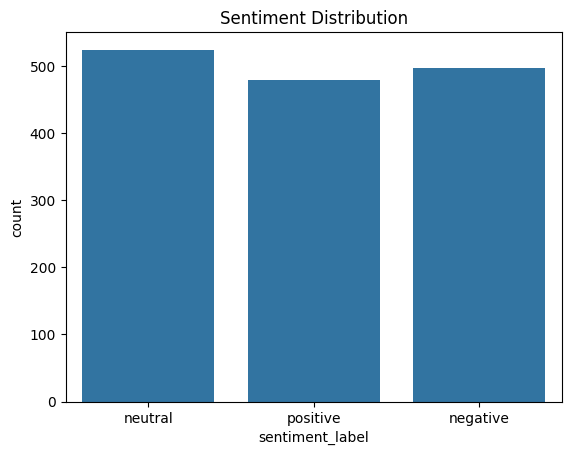

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment_label', data=df)

plt.title("Sentiment Distribution")

plt.show()

## Task 2: Text Preprocessing

In [12]:
import re
import nltk
import nltk
nltk.download('stopwords')

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def preprocess_text(text):

    # Lowercase
    text = text.lower()

    # Remove special characters
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['cleaned_text'] = df['customer_message'].apply(preprocess_text)

print(df[['customer_message', 'cleaned_text']].head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                        cleaned_text  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


## Task 3: Text Vectorization

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['cleaned_text']).toarray()

print(X.shape)

(1500, 146)


In [14]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(df['sentiment_label'])

print(le.classes_)

['negative' 'neutral' 'positive']


## Task 4: Baseline Model

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [17]:
y_pred = model.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       109
           1       1.00      1.00      1.00       104
           2       1.00      1.00      1.00        87

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



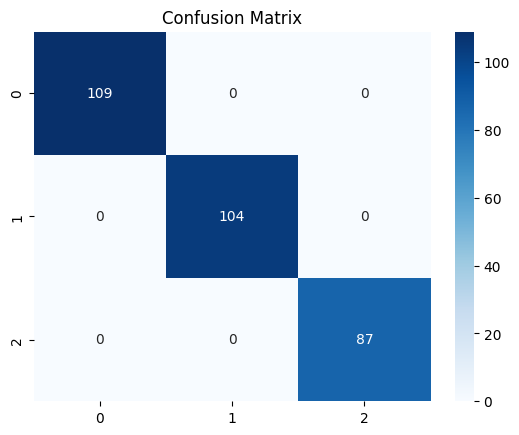

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")

plt.savefig("results/model_evaluation.png")

plt.show()

## Task 5: Sequence Model (LSTM)

In [21]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer(num_words=5000)

tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])

X_seq = pad_sequences(sequences, maxlen=100)

In [22]:
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential()

# Embedding Layer
lstm_model.add(Embedding(input_dim=5000, output_dim=64, input_length=100))

# LSTM Layer
lstm_model.add(LSTM(64))

# Output Layer
lstm_model.add(Dense(3, activation='softmax'))

lstm_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 100, 64)           320000    
                                                                 
 lstm (LSTM)                 (None, 64)                33024     
                                                                 
 dense (Dense)               (None, 3)                 195       
                                                                 
Total params: 353219 (1.35 MB)
Trainable params: 353219 (1.35 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [24]:
history = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/5
30/30 [==============================] - 8s 161ms/step - loss: 1.0236 - accuracy: 0.7115 - val_loss: 0.8351 - val_accuracy: 0.8333
Epoch 2/5
30/30 [==============================] - 1s 50ms/step - loss: 0.4497 - accuracy: 0.9479 - val_loss: 0.1422 - val_accuracy: 1.0000
Epoch 3/5
30/30 [==============================] - 2s 82ms/step - loss: 0.0583 - accuracy: 0.9990 - val_loss: 0.0246 - val_accuracy: 1.0000
Epoch 4/5
30/30 [==============================] - 2s 60ms/step - loss: 0.0143 - accuracy: 1.0000 - val_loss: 0.0070 - val_accuracy: 1.0000
Epoch 5/5
30/30 [==============================] - 2s 67ms/step - loss: 0.0046 - accuracy: 1.0000 - val_loss: 0.0031 - val_accuracy: 1.0000


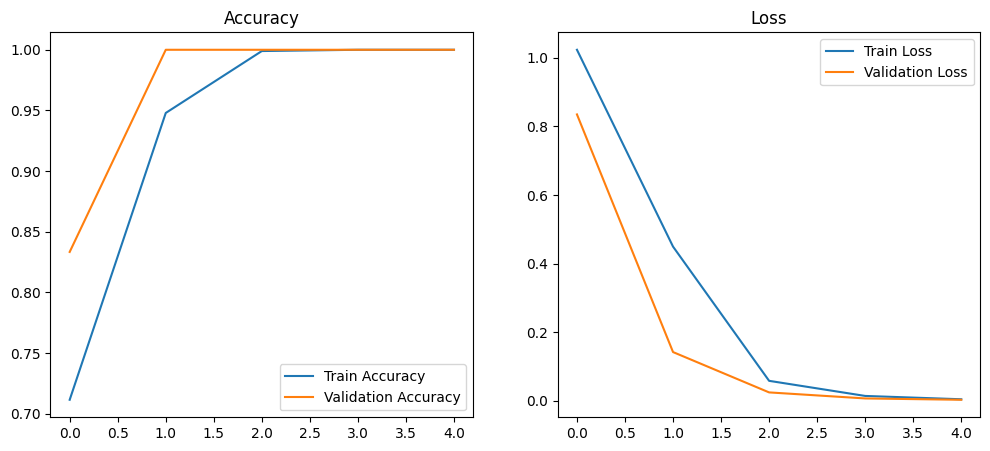

In [25]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.savefig("results/model_evaluation.png")

plt.show()

In [26]:
sample_texts = [
    "The product quality is amazing",
    "I am very disappointed with the service",
    "The issue was resolved successfully"
]

sample_cleaned = [preprocess_text(text) for text in sample_texts]

sample_seq = tokenizer.texts_to_sequences(sample_cleaned)

sample_pad = pad_sequences(sample_seq, maxlen=100)

predictions = lstm_model.predict(sample_pad)

predicted_labels = le.inverse_transform(predictions.argmax(axis=1))

for text, label in zip(sample_texts, predicted_labels):

    print("Message:", text)
    print("Predicted Sentiment:", label)
    print()

1/1 [==============================] - 0s 488ms/step
Message: The product quality is amazing
Predicted Sentiment: positive

Message: I am very disappointed with the service
Predicted Sentiment: positive

Message: The issue was resolved successfully
Predicted Sentiment: positive



In [28]:
with open("results/sample_predictions.txt", "w") as f:

    for text, label in zip(sample_texts, predicted_labels):

        f.write(f"Message: {text}\n")
        f.write(f"Predicted Sentiment: {label}\n\n")

## Task 6: Attention and Transformer Reflection

Why are transformers important in NLP?

Transformers can process entire sentences in parallel and understand long-range relationships between words better than traditional RNNs or LSTMs.

Benefits of Transformers
Faster training
Better contextual understanding
Handles long sequences efficiently
State-of-the-art performance in NLP tasks
Role of Attention

Attention helps the model focus on the most important words in a sentence while making predictions.

Example:
In the sentence:

“The delivery was late but the support team was helpful”

Attention helps identify important sentiment words like:

late
helpful